<a href="https://colab.research.google.com/github/JoaoVitorCoelhoG/Aprendizado-Profundo/blob/main/cm204_lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Instituto Tecnológico de Aeronáutica – ITA**

**CM-204 – Aprendizado Profundo**

**Professores:**

Marcos Ricardo Omena de Albuquerque Maximo

André Oliveira Françani

Claude


# Laboratório 6 – Processamento de Linguagem com RNN

**Observação**:
- **NÃO** exclua células, pois isto pode gerar problemas com o autocorretor!
- Para editar este notebook, salve uma cópia no seu Drive em ``File > Save a copy in Drive``.
- Neste laboratório, é aconselhável utilizar a GPU do Colab para o treinamento da rede. Para usar a GPU, faça o seguinte:
  - Na aba superior, selecione o menu "*Runtime*" ("Ambiente de execução");
  - Clique em "*Change runtime type*" ("Alterar tipo de ambiente de execução");
  - Selecione "GPU" na seção "*Hardware accelerator*" ("Acelerador de *hardware*") e salve.

  Verifique se a GPU está disponível executando o seguinte comando no notebook:


In [1]:
!nvidia-smi

Sun Jun 21 20:46:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...    On  |   00000000:01:00.0  On |                  N/A |
| N/A   59C    P8              7W /   30W |      61MiB /   6144MiB |     44%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

  Lembre-se de que a disponibilidade de GPU no Google Colab pode variar e nem sempre é garantida. Portanto, aconselhamos a implementar a sua rede neural na CPU, e fazer a troca para a GPU apenas na hora de executar o treinamento da rede para acelerar o processamento.

  Claro que rodar localmente é permitido. Na verdade, o laboratório foi desenvolvido localmente. As instruções falam do Google Colab por este ser costumeiramente o método preferido pelos alunos. Também recomenda-se o uso de GPU caso decida rodar localmente.

# 1. Introdução

Neste laboratório, você aprenderá a implementar redes neurais recorrentes capazes de analisar textos e classificar se uma avaliação é positiva ou negativa. Você trabalhará com a base de dados [IMDB](https://ai.stanford.edu/~amaas/data/sentiment/) que contém 25.000 avaliações de filmes rotuladas, com o objetivo de construir um modelo de aprendizado de máquina capaz de classificar novas avaliações.

# 2. Descrição do Problema

O problema consiste em classificar avaliações de filmes da base de dados [IMDB](https://ai.stanford.edu/~amaas/data/sentiment/). Essa base de dados contém 25.000 avaliações de filmes rotuladas por sentimento (positivo ou negativo).

Você implementará redes recorrentes (RNNs) usando três tipos diferentes de células: a célula básica (também chamada de `vanilla'), LSTM (*Long-Short Term Memory*) e GRU (*Gated Recurrent Unit*). Por se tratar de um problema de classificação binária, a última camada deve ser um neurônio com função de ativação "sigmóide". Além disso, será usada a ideia de *word embedding*, porém a matriz do *embedding* será inicializada aleatoriamente e aprendida a partir dos dados, o que é uma abordagem suficiente para os propósitos do laboratório.

# 3. Código Base

O código fornecido já lê a base de dados e faz todo o pré-processamento necessário para treinar a rede neural. Além disso, também foi fornecido o código que treina a rede com a função custo "entropia cruzada binária" e otimizador RMSprop. Assim, seu objetivo é apenas implementar os modelos recorrentes e um código para avaliação desses modelos.

# 4. Classificando Avaliações de Filmes com LSTM

## 4.1. Baixando e Entendendo a IMDB

Para baixar o *dataset* IMDB, usaremos o pacote `datasets` do Hugging Face. Neste caso, o *dataset* vem apenas como um conjunto de *strings* com o *label* dizendo que é avaliação negativa (0) ou positiva (1). Para transformar em algo que podemos colocar como entrada no nosso modelo, vamos primeiramente pré-processar o *dataset*.

Como o *dataset* possui uma grande quantidade de palavras, define-se um vocabulário de 10000 palavras (`max_features`). Neste vocabulário, adota-se 3 *tokens* especiais: `<PAD>` (0), `<START>` (1) e `OOV` (2), que representam *padding*, início de sentença e fora do vocabulário (*out of vocabulary*). Com isso, as 99997 palavras restantes do vocabulário são escolhidas dentre as mais frequências no *dataset*.

Note que o código separa 25000 amostras para treino e 25000 amostras para teste.

In [1]:
from datasets import load_dataset
import numpy as np
import re
from collections import Counter

max_features = 10000  # vocabulary size
max_len = 500

# Special indices — same convention as the numpy/Keras version
PAD_IDX   = 0
START_IDX = 1
OOV_IDX   = 2
INDEX_FROM = 3  # first real word index

def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())

# Load raw text
dataset = load_dataset("stanfordnlp/imdb")
train_data = dataset["train"]
test_data  = dataset["test"]

# Build vocab from training set only — top max_features words
counter = Counter()
for sample in train_data:
    counter.update(tokenize(sample["text"]))

vocab_words = [word for word, _ in counter.most_common(max_features - INDEX_FROM)]
word_to_idx = {word: i + INDEX_FROM for i, word in enumerate(vocab_words)}

# Encode: prepend start token, map unknowns to OOV_IDX
def encode(text):
    return [START_IDX] + [word_to_idx.get(tok, OOV_IDX) for tok in tokenize(text)]

x_train = [encode(s["text"]) for s in train_data]
y_train = np.array([s["label"] for s in train_data], dtype=np.float32)
x_test  = [encode(s["text"]) for s in test_data]
y_test  = np.array([s["label"] for s in test_data], dtype=np.float32)

In [2]:
print(len(vocab_words), "Unique tokens in vocab_words")

9997 Unique tokens in vocab_words


In [3]:
print("Most frequent words: ", vocab_words[:10])

Most frequent words:  ['the', 'and', 'a', 'of', 'to', 'is', 'br', 'it', 'in', 'i']


As variáveis "y_train" e "y_test" são listas com os rótulos de classificação (0 = avaliação negativa e 1 = avaliação positiva).
Para entender o que está em "x_train" e "x_test", vamos printar as primeiras 10 primeiras palavras da primeira amostra. Lembrando que a base de dados já codifica as palavras em números inteiros de acordo com sua frequência na base de dados.

In [4]:
print(dataset["test"][0]["text"])

I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully one-dimensional characters cannot be overcome with a 'sci-fi' setting. (I'm sure there are those of you out there who think Babylon 5 is good sci-fi TV. It's not. It's clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It's really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it's rubbish as they have to alway

Abaixo, pode-se visualizar como fica uma sentença fornecida para a rede.

In [5]:
import json

# Use the default parameters consistent with the IMDB dataset format
start_char = 1
oov_char = 2
index_from = 3

inverted_word_index = dict()
for i in range(len(vocab_words)):
    inverted_word_index[i + index_from] = vocab_words[i]
# Update inverted_word_index to include start_char and oov_char
inverted_word_index[start_char] = "[START]"
inverted_word_index[oov_char] = "[OOV]"

# # Decode the first sequence in the dataset
decoded_sequence = " ".join(inverted_word_index[i] for i in x_test[0])
print("First sentence in the dataset:")
print(dataset["test"][0]["text"])
print("First sentence processed for our training:")
print(decoded_sequence)


First sentence in the dataset:
I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully one-dimensional characters cannot be overcome with a 'sci-fi' setting. (I'm sure there are those of you out there who think Babylon 5 is good sci-fi TV. It's not. It's clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It's really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it'

Agora vamos ver o porquê de fazermos "padding". Note que as amostras de treino não possuem a mesma quantidade de palavras.

In [6]:
print("Training sample 0: ", len(x_train[0]))
print("Training sample 1: ", len(x_train[1]))
print("Training sample 2: ", len(x_train[2]))

Training sample 0:  296
Training sample 1:  228
Training sample 2:  98


Com o *padding*, adicionamos o inteiro "0" para que todas as amostras possuam o mesmo tamanho. Caso a sentença passe de 500 palavras, considerando apenas as 500 primeiras palavras.

In [7]:
max_len = 500  # Cuts off texts after this number of words (among the max_features most common words)

# Pad / truncate to fixed length
def pad_sequences(sequences, maxlen, value=PAD_IDX):
    result = np.zeros((len(sequences), maxlen), dtype=np.int32)
    for i, seq in enumerate(sequences):
        seq = seq[-maxlen:]
        result[i, -len(seq):] = seq
    return result

x_train = pad_sequences(x_train, maxlen=max_len)
x_test  = pad_sequences(x_test,  maxlen=max_len)
print("x_train shape:", x_train.shape)  # (25000, 500)
print("x_test shape: ", x_test.shape)   # (25000, 500)

x_train shape: (25000, 500)
x_test shape:  (25000, 500)


## 4.2. Implementação da Rede Recorrente

Como já exploramos e entendemos a base de dados na Seção 4.1, vamos lê-la novamente de forma resumida na célula abaixo.

<font color='red'>**Implemente agora os modelos recorrentes para a classificação das avaliações de filmes**.</font>

**Descrição das camadas**:

- A primeira camada deve ser um *Embedding* com dimensão de entrada igual ao número de *features* (número de palavras na nossa base de dados) e dimensão de saída 32;
- A segunda camada deve ser uma camada RNN (com o tipo de célula escolhido através do parâmetro `cell_type` do construtor) com 32 unidades.
- A terceira e última camada deve ser **um único neurônio** com função de ativação "sigmoide" para realizar a classificação binária. A entrada desta última camada é a última saída da camada RNN.

**Observação**: caso esteja com dificuldades, veja as dicas na Seção 6.

In [13]:
import torch
import torch.nn as nn

class RecurrentModel(nn.Module):
    """
    A recurrent neural network for sentiment analysis, with a choice of RNN cell type (basic RNN, LSTM, or GRU).
    @param max_features: Size of the vocabulary (number of unique tokens)
    @param cell_type: Type of RNN cell to use ("basic", "lstm", or "gru")
    @param embed_dim: Dimensionality of the word embeddings
    @param num_units: Number of hidden units in the RNN layer
    """
    def __init__(self, max_features: int, cell_type: str ="basic", embed_dim: int = 32, num_units: int = 32):
        """
        Initializes the model architecture based on the specified cell type and parameters.
        @param max_features: Size of the vocabulary (number of unique tokens)
        @param cell_type: Type of RNN cell to use ("basic", "lstm", or "gru")
        @param embed_dim: Dimensionality of the word embeddings
        @param num_units: Number of hidden units in the RNN layer
        """
        super().__init__()
        self.cell_type = cell_type
        # Implement
        self.embedding = nn.Embedding(max_features, embed_dim, padding_idx=PAD_IDX)

        if self.cell_type == "basic":
            self.rnn = nn.RNN(embed_dim, num_units, batch_first=True)   
        elif self.cell_type == "lstm":
            self.rnn = nn.LSTM(embed_dim,num_units, batch_first=True)
        elif self.cell_type == "gru":
            self.rnn = nn.GRU(embed_dim, num_units, batch_first=True)
        self.fc = nn.Linear(in_features=num_units,out_features=1)       

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Inference method for the model. Takes a batch of input sequences and returns the predicted probabilities.
        @param x: Input tensor of shape (batch_size, sequence_length) containing token indices
        @return: Output tensor of shape (batch_size, 1) containing predicted probabilities for the positive class
        """
        # Implement
        x = self.embedding(x)
        output, _ = self.rnn(x)
        output = output[:,-1,:]
        return torch.sigmoid(self.fc(output))
        
        





In [14]:
print("Basic (vanilla) RNN model:")
basic_model = RecurrentModel(max_features, "basic")
print(basic_model)
total_params = sum(p.numel() for p in basic_model.parameters())
assert(total_params == 322145), f"Expected 322,145 parameters, got {total_params}"

Basic (vanilla) RNN model:
RecurrentModel(
  (embedding): Embedding(10000, 32, padding_idx=0)
  (rnn): RNN(32, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [15]:
print("LSTM model:")
lstm_model = RecurrentModel(max_features, "lstm")
print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters())
assert(total_params == 328481), f"Expected 328,481 parameters, got {total_params}"

LSTM model:
RecurrentModel(
  (embedding): Embedding(10000, 32, padding_idx=0)
  (rnn): LSTM(32, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [16]:
print("GRU model:")
gru_model = RecurrentModel(max_features, "gru")
print(gru_model)
total_params = sum(p.numel() for p in gru_model.parameters())
assert(total_params == 326369), f"Expected 326,369 parameters, got {total_params}"

GRU model:
RecurrentModel(
  (embedding): Embedding(10000, 32, padding_idx=0)
  (rnn): GRU(32, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from math import inf

def train_model(model: nn.Module, criterion: nn.Module, optimizer: torch.optim.Optimizer,
                device: torch.device, batch_size: int = 32, num_epochs: int = 10):
    """
    Train the given recurrent model using the provided criterion and optimizer.
    @param model: The PyTorch model to train
    @param criterion: The loss function to optimize
    @param optimizer: The optimization algorithm to use for updating model parameters
    @param device: The device (CPU or GPU) to run the training on
    @param batch_size: The number of samples per training batch
    @param num_epochs: The number of epochs to train the model for
    @return: The trained model and a history dictionary containing training/validation loss and accuracy per
             epoch
    """
    # Prepare tensors
    x_train_t = torch.tensor(x_train, dtype=torch.long)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

    # 80/20 train/validation split
    split = int(len(x_train_t) * 0.8)
    x_tr, x_val = x_train_t[:split], x_train_t[split:]
    y_tr, y_val = y_train_t[:split], y_train_t[split:]

    train_loader = DataLoader(TensorDataset(x_tr, y_tr), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TensorDataset(x_val, y_val), batch_size=batch_size)

    history = {'acc': [], 'val_acc': [], 'loss': [], 'val_loss': []}

    best_v_loss = inf

    for epoch in range(num_epochs):
        model.train()
        tr_loss = tr_correct = tr_total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * len(xb)
            tr_correct += ((preds > 0.5).float() == yb).sum().item()
            tr_total += len(xb)

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                v_loss += criterion(preds, yb).item() * len(xb)
                v_correct += ((preds > 0.5).float() == yb).sum().item()
                v_total += len(xb)
                if v_loss < best_v_loss:
                    best_v_loss = v_loss
                    # Save the best model
                    torch.save(model.state_dict(), f'best_{model.cell_type}.pt')

        history['loss'].append(tr_loss / tr_total)
        history['val_loss'].append(v_loss / v_total)
        history['acc'].append(tr_correct / tr_total)
        history['val_acc'].append(v_correct / v_total)
        print(f"Epoch {epoch+1}/10 - loss: {history['loss'][-1]:.4f} - acc: {history['acc'][-1]:.4f}"
            f" - val_loss: {history['val_loss'][-1]:.4f} - val_acc: {history['val_acc'][-1]:.4f}")

    # Save the last model
    torch.save(model.state_dict(), f'last_{model.cell_type}.pt')

    return model, history

Treine suas redes executando as células abaixo (**Não precisa alterar nada**):

In [18]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from math import inf

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

criterion = nn.BCELoss()

Using device: cuda


In [19]:
def plot_history(history: dict, model_name: str):
    """
    Plots the training and validation loss and accuracy for a given model.
    @param history: A dictionary containing the training and validation metrics
    @param model_name: The name of the model (used for plot titles and filenames)
    """
    loss = history['loss']
    val_loss = history['val_loss']
    acc = history['acc']
    val_acc = history['val_acc']
    epochs = range(1, len(acc) + 1)

    plt.figure()
    plt.plot(epochs, loss,     'k', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(f'Training and validation loss - {model_name}')
    plt.legend()
    plt.savefig(f'{model_name}_loss.png')

    plt.figure()
    plt.plot(epochs, acc,     'k', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title(f'Training and validation accuracy - {model_name}')
    plt.legend()
    plt.savefig(f'{model_name}_acc.png')

Epoch 1/10 - loss: 0.6404 - acc: 0.6392 - val_loss: 0.9673 - val_acc: 0.2594
Epoch 2/10 - loss: 0.5768 - acc: 0.7054 - val_loss: 0.9145 - val_acc: 0.4398
Epoch 3/10 - loss: 0.5378 - acc: 0.7386 - val_loss: 1.0389 - val_acc: 0.3150
Epoch 4/10 - loss: 0.5052 - acc: 0.7620 - val_loss: 0.9138 - val_acc: 0.4484
Epoch 5/10 - loss: 0.4795 - acc: 0.7844 - val_loss: 0.7405 - val_acc: 0.6172
Epoch 6/10 - loss: 0.4339 - acc: 0.8115 - val_loss: 0.6688 - val_acc: 0.7046
Epoch 7/10 - loss: 0.4547 - acc: 0.8006 - val_loss: 0.7057 - val_acc: 0.6794
Epoch 8/10 - loss: 0.4128 - acc: 0.8268 - val_loss: 0.5960 - val_acc: 0.7238
Epoch 9/10 - loss: 0.3968 - acc: 0.8357 - val_loss: 0.4737 - val_acc: 0.8048
Epoch 10/10 - loss: 0.3820 - acc: 0.8459 - val_loss: 0.6823 - val_acc: 0.6712


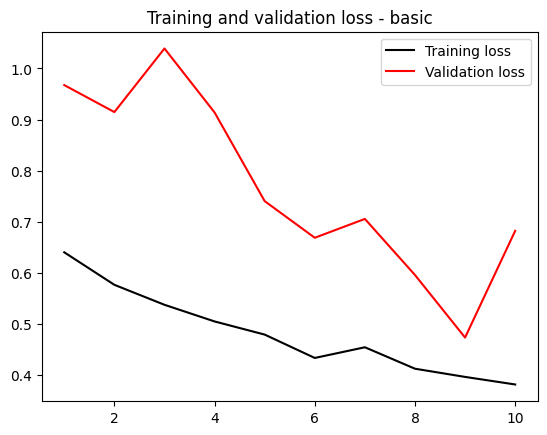

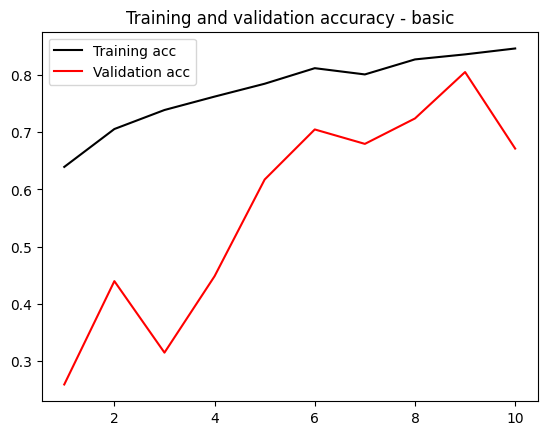

In [20]:
basic_model = RecurrentModel(max_features, "basic").to(device)
optimizer = torch.optim.RMSprop(basic_model.parameters(), lr=1e-3)

basic_model, history = train_model(basic_model, criterion, optimizer, device)

plot_history(history, basic_model.cell_type)

Epoch 1/10 - loss: 0.6166 - acc: 0.6523 - val_loss: 0.8667 - val_acc: 0.4996
Epoch 2/10 - loss: 0.5724 - acc: 0.7123 - val_loss: 0.8131 - val_acc: 0.6312
Epoch 3/10 - loss: 0.4902 - acc: 0.7622 - val_loss: 1.0550 - val_acc: 0.6042
Epoch 4/10 - loss: 0.4298 - acc: 0.8056 - val_loss: 0.5682 - val_acc: 0.7430
Epoch 5/10 - loss: 0.3685 - acc: 0.8438 - val_loss: 0.4670 - val_acc: 0.8098
Epoch 6/10 - loss: 0.3260 - acc: 0.8668 - val_loss: 0.4811 - val_acc: 0.7916
Epoch 7/10 - loss: 0.2974 - acc: 0.8827 - val_loss: 0.4406 - val_acc: 0.8158
Epoch 8/10 - loss: 0.2714 - acc: 0.8948 - val_loss: 0.4214 - val_acc: 0.8592
Epoch 9/10 - loss: 0.2403 - acc: 0.9093 - val_loss: 1.1406 - val_acc: 0.5356
Epoch 10/10 - loss: 0.2177 - acc: 0.9170 - val_loss: 0.8309 - val_acc: 0.6980


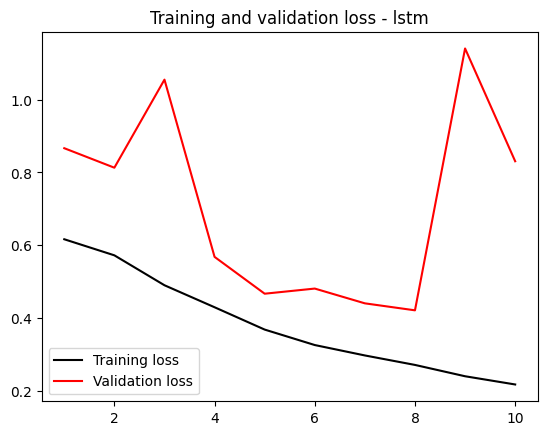

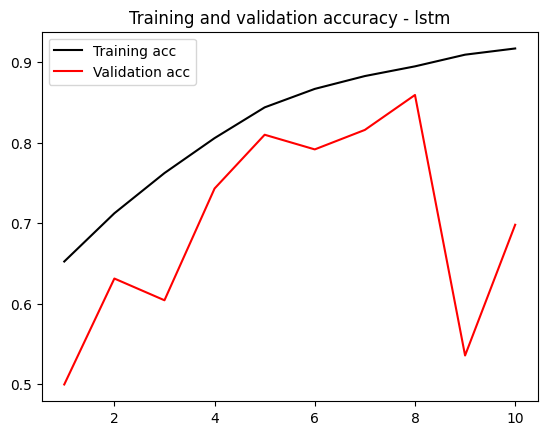

In [21]:
lstm_model = RecurrentModel(max_features, "lstm").to(device)
optimizer = torch.optim.RMSprop(lstm_model.parameters(), lr=1e-3)

lstm_model, history = train_model(lstm_model, criterion, optimizer, device)

plot_history(history, lstm_model.cell_type)

Epoch 1/10 - loss: 0.6092 - acc: 0.6675 - val_loss: 1.2664 - val_acc: 0.2320
Epoch 2/10 - loss: 0.4902 - acc: 0.7696 - val_loss: 0.8029 - val_acc: 0.5744
Epoch 3/10 - loss: 0.4105 - acc: 0.8192 - val_loss: 0.6982 - val_acc: 0.6730
Epoch 4/10 - loss: 0.3391 - acc: 0.8608 - val_loss: 0.4531 - val_acc: 0.8010
Epoch 5/10 - loss: 0.2819 - acc: 0.8888 - val_loss: 0.5207 - val_acc: 0.7622
Epoch 6/10 - loss: 0.2365 - acc: 0.9113 - val_loss: 0.5781 - val_acc: 0.7690
Epoch 7/10 - loss: 0.2072 - acc: 0.9221 - val_loss: 0.5661 - val_acc: 0.7790
Epoch 8/10 - loss: 0.1756 - acc: 0.9363 - val_loss: 0.7422 - val_acc: 0.7330
Epoch 9/10 - loss: 0.1503 - acc: 0.9466 - val_loss: 0.5876 - val_acc: 0.7916
Epoch 10/10 - loss: 0.1271 - acc: 0.9577 - val_loss: 0.5775 - val_acc: 0.7910


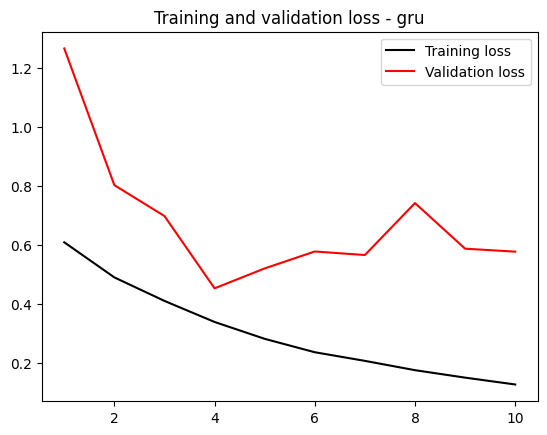

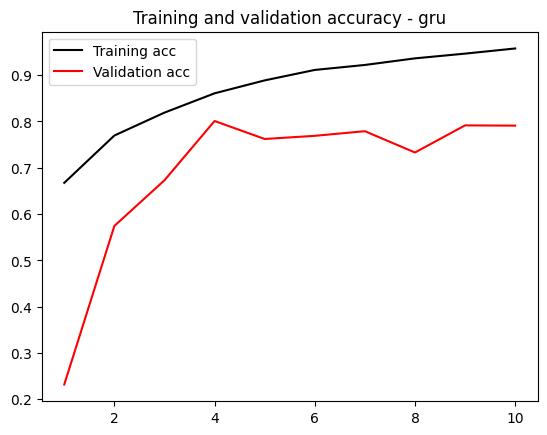

In [22]:
gru_model = RecurrentModel(max_features, "gru").to(device)
optimizer = torch.optim.RMSprop(gru_model.parameters(), lr=1e-3)

gru_model, history = train_model(gru_model, criterion, optimizer, device)

plot_history(history, gru_model.cell_type)

<font color='red'>**Inclua os gráficos acima no seu relatório! Perceba que eles são salvos automaticamente como arquivos .png. Comente os resultados obtidos.**</font>

In [23]:
def evaluate_model(model: nn.Module, criterion: nn.Module, batch_size: int = 32):
    """
    Evaluates the given model on the test set and returns the average loss and accuracy.
    @param model: The PyTorch model to evaluate
    @param criterion: The loss function to use for evaluation
    @param batch_size: The number of samples per evaluation batch
    @return: A tuple (test_loss, test_acc) containing the average loss and accuracy on the test set
    """
    model.eval()

    # Implement
    x_test_t = torch.tensor(x_test, dtype=torch.long)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
    
    test_loader = DataLoader(TensorDataset(x_test_t, y_test_t), batch_size=batch_size)
    
    t_loss = 0
    t_acc = 0
    tr_total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            t_loss += loss.item() * len(xb)
            t_acc += ((preds > 0.5).float() == yb).sum().item()
            tr_total += len(xb)
            
        test_loss = t_loss/tr_total
        test_acc = t_acc/tr_total

        return test_loss, test_acc
   

    return test_loss, test_acc

In [24]:
# Evaluate best models on test data
basic_model = RecurrentModel(max_features, "basic").to(device)
basic_model.load_state_dict(torch.load('best_basic.pt'))
lstm_model = RecurrentModel(max_features, "lstm").to(device)
lstm_model.load_state_dict(torch.load('best_lstm.pt'))
gru_model = RecurrentModel(max_features, "gru").to(device)
gru_model.load_state_dict(torch.load('best_gru.pt'))

basic_loss, basic_acc = evaluate_model(basic_model, criterion)
lstm_loss, lstm_acc = evaluate_model(lstm_model, criterion)
gru_loss, gru_acc = evaluate_model(gru_model, criterion)

print(f"Basic RNN - Test Loss: {basic_loss:.4f}, Test Acc: {basic_acc:.4f}"
      f"\nLSTM      - Test Loss: {lstm_loss:.4f}, Test Acc: {lstm_acc:.4f}"
      f"\nGRU       - Test Loss: {gru_loss:.4f}, Test Acc: {gru_acc:.4f}")

Basic RNN - Test Loss: 0.4959, Test Acc: 0.7858
LSTM      - Test Loss: 0.3816, Test Acc: 0.8346
GRU       - Test Loss: 0.3705, Test Acc: 0.8523


**Observação**: A acurácia no conjunto de validação durante o treinamento é um tanto ruidosa. Se você obter mais que 80% de acurácia no teste usando LSTM e GRU, pode considerar sucesso.

<font color='red'>**Monte uma tabela no seu relatório para apresentar os resultados obtidos na célula anterior! Comente os resultados obtidos e se eles condizem com a teoria.**</font>

# 5. Entrega

A entrega consiste do notebook no formato **.ipynb** e de um relatório, submetida através do Google Classroom. Modificações nos arquivos do código base são permitidas, desde que o nome e a interface dos scripts “main” não sejam alterados. A princípio, não há limitação de número de páginas para o relatório, mas pede-se que seja sucinto. O relatório deve conter:
- Figuras que comprovem o funcionamento do seu código.
- Demais solicitações feitas ao longo do roteiro.

Por limitações do Google Classroom (e por motivo de facilitar a automatização da correção), entregue seu laboratório com todos os arquivos num único arquivo **.zip** (**não** utilize outras tecnologias de compactação de arquivos) com o seguinte padrão de nome: **“<login_email_google_education>_labX.zip”**. Por exemplo, no meu caso, meu login Google Education é **marcos.maximo**, logo eu entregaria o lab 1 como **“marcos.maximo_lab1.zip”**. **Não** crie subpastas para os arquivos da sua entrega, **deixe todos os arquivos na “raiz” do .zip**.

# 6. Dicas

- Para criar a camada de *Embedding* no PyTorch:
```python
self.embedding = nn.Embedding(input_dim, output_dim, padding_idx=0)
```
em que *input_dim* é o tamanho do vocabulário e *output_dim* é a dimensão de saída do embedding. Veja a [documentação](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html) para mais detalhes. Perceba que os pesos do *Embedding* são inicializados aleatoriamente neste caso. É possível pedir para o PyTorch inicializar pesos pré-treinados para o *Embedding*, mas não há necessidade de fazer isto neste laboratório.


- Para adicionar camadas de células do tipo básica, *LSTM* e *GRU* no PyTorch (respectivamente):
```python
self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
```
```python
self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
```
```python
self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
```
em que *input_size* é a dimensão de entrada (= *output_dim* do Embedding) e *hidden_size* é o número de unidades. Use `batch_first=True` para que a entrada seja `(batch, seq, features)`. Veja a [documentação](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html) para mais detalhes.

- Para obter apenas a última saída de uma RNN com célula básica ou de uma GRU:
```python
output, hn = self.rnn(x)
output = output[:, -1, :]
```
- Para obter apenas a última saída de uma LSTM:
```python
output, (hn, cn) = self.rnn(x)
output = output[:, -1, :]
```

- Para o classificador binário (camada de saída):

No construtor:
```python
self.fc = nn.Linear(hidden_size, 1)
```
No `forward()`:
```python
return torch.sigmoid(self.fc(output))
```
Veja a [documentação de ativações](https://pytorch.org/docs/stable/nn.functional.html#non-linear-activation-functions) para mais detalhes.